In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder

In [4]:
df = pd.read_csv("dataset.csv")
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [5]:
df['track_genre'].unique()

array(['acoustic', 'afrobeat', 'alt-rock', 'alternative', 'ambient',
       'anime', 'black-metal', 'bluegrass', 'blues', 'brazil',
       'breakbeat', 'british', 'cantopop', 'chicago-house', 'children',
       'chill', 'classical', 'club', 'comedy', 'country', 'dance',
       'dancehall', 'death-metal', 'deep-house', 'detroit-techno',
       'disco', 'disney', 'drum-and-bass', 'dub', 'dubstep', 'edm',
       'electro', 'electronic', 'emo', 'folk', 'forro', 'french', 'funk',
       'garage', 'german', 'gospel', 'goth', 'grindcore', 'groove',
       'grunge', 'guitar', 'happy', 'hard-rock', 'hardcore', 'hardstyle',
       'heavy-metal', 'hip-hop', 'honky-tonk', 'house', 'idm', 'indian',
       'indie-pop', 'indie', 'industrial', 'iranian', 'j-dance', 'j-idol',
       'j-pop', 'j-rock', 'jazz', 'k-pop', 'kids', 'latin', 'latino',
       'malay', 'mandopop', 'metal', 'metalcore', 'minimal-techno', 'mpb',
       'new-age', 'opera', 'pagode', 'party', 'piano', 'pop-film', 'pop',
       'pow

Filtrando o df para apenas 6 generos musicais

In [6]:
df = df[df['track_genre'].isin(['pop', 'country', 'hip-hop', 'punk-rock', 'latin', 'edm'])]

In [7]:
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,55999.500000,30.654667,209471.629333,0.633223,0.696505,5.462333,-6.112977,0.612667,0.079936,0.206556,0.017823,0.188678,0.540378,122.621426,3.934667
std,24686.735421,31.566704,50822.054070,0.147810,0.178770,3.533647,2.550590,0.487181,0.072016,0.236519,0.093238,0.151090,0.221123,30.268795,0.344603
min,19000.000000,0.000000,42440.000000,0.132000,0.056500,0.000000,-24.843000,0.000000,0.023200,0.000001,0.000000,0.015000,0.034100,48.578000,1.000000
25%,30499.750000,0.000000,176658.000000,0.529000,0.581000,2.000000,-7.289250,0.000000,0.036400,0.026600,0.000000,0.096300,0.371000,97.058750,4.000000
50%,59499.500000,35.000000,203640.500000,0.647000,0.721500,6.000000,-5.662000,1.000000,0.052700,0.112000,0.000000,0.128000,0.545500,120.122000,4.000000
75%,81499.250000,63.000000,233403.500000,0.743000,0.837250,8.000000,-4.343000,1.000000,0.089925,0.302000,0.000078,0.237000,0.711000,142.646750,4.000000
max,85999.000000,100.000000,620320.000000,0.964000,0.998000,11.000000,0.366000,1.000000,0.621000,0.990000,0.984000,0.988000,0.977000,215.513000,5.000000


In [8]:
# Apagando colunas que não vão ajudar na classificação das musicas
df.drop(columns=["Unnamed: 0", "track_id", "track_name", "artists", "album_name", "time_signature"], axis=1, inplace=True)

print(df.isnull().sum())
df.dropna(inplace=True)

popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
track_genre         0
dtype: int64


Definindo o target e separando em treino e teste

Uma coisa importante que aprendi: Usar os dados de teste (X_test e y_test) para fazer ajustes com base na predição gerada não é uma boa, pois geralmente tem que fazer ajustes no modelo, e se eu usar os valores de test, vou estar meio que usando a interferência deles no modelo final, e isso não é tão bom, pois aqui o objetivo é usar eles realmente como valores para o calculo de desempenho sem nenhum tipo de interferencia. E é por isso que é uma boa prática se usar os valores de val, basicamente vou separar uma parte dos dados para eles, e usar a predição gerada a partir deles para realizar os devidos ajustes no modelo final

In [9]:
y_encoder = df['track_genre']

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_encoder)

In [10]:
X = df.loc[:, (df.columns != 'track_genre')]


# Deixo 80% do todo para treino e 20% do todo para teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# A partir do todo do treino, vou deixar 75% para treino e 25% para validação
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

A professora aplicou StandarScaler, em algoritmos baseados em árvore de desição, não é necessário, mas também não atrapalha em nada

In [11]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [12]:
xgb_classifier = xgb.XGBClassifier(random_state=42)

xgb_classifier.fit(X_train, y_train)

y_pred = xgb_classifier.predict(X_val)

test_accuracy = accuracy_score(y_val, y_pred)
print(f"Acurácia: {test_accuracy:.4f}")

print("\nClassification Report:\n", classification_report(y_val, y_pred))

print("\nMatriz de confusão:\n", confusion_matrix(y_val, y_pred))

Acurácia: 0.7075

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.81      0.78       197
           1       0.76      0.74      0.75       208
           2       0.64      0.58      0.61       206
           3       0.70      0.64      0.67       202
           4       0.55      0.63      0.59       185
           5       0.83      0.85      0.84       202

    accuracy                           0.71      1200
   macro avg       0.71      0.71      0.71      1200
weighted avg       0.71      0.71      0.71      1200


Matriz de confusão:
 [[160   7   3   6   7  14]
 [  8 153   7   8  20  12]
 [  0  18 119  26  41   2]
 [ 15   4  26 130  22   5]
 [ 10  16  27  15 116   1]
 [ 18   4   4   1   4 171]]


Treinando de novo, mas agora definindo hiperparâmetros

In [ ]:
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 6, 9],
    'min_child_weight': [1, 3 ,5],
    'subsample': [0.7, 0.85, 1.0],
    'colsample_bytree': [0.7, 0.85, 1.0],
    'reg_alpha': [0, 0.01, 0.1, 1, 10, 100],
    'reg_lambda': [0.5, 0.7, 1, 1.3]
}

xgb_model = xgb.XGBClassifier(random_state=42)

# Usando validação cruzada para achar os melhores hiperparâmetros para o modelo
grid_search = RandomizedSearchCV(xgb_model, param_grid, cv=10, scoring="accuracy", n_iter=100, n_jobs=-1, verbose=2, random_state=42)
grid_search.fit(X_train, y_train)

best_xgb = grid_search.best_estimator_

print("Melhores parâmetros:", grid_search.best_params_)
print("Melhor acurácia:", grid_search.best_score_)

Fitting 10 folds for each of 100 candidates, totalling 1000 fits
Melhores parâmetros: {'subsample': 0.85, 'reg_lambda': 1.3, 'reg_alpha': 0.01, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 9, 'learning_rate': 0.1, 'colsample_bytree': 0.85}
Melhor acurácia: 0.7280555555555556


In [15]:
y_pred = best_xgb.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)
print("Acurácia: ", test_accuracy)

print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("\nMatriz de confusão:\n", confusion_matrix(y_test, y_pred))

Acurácia:  0.71

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.80      0.79       215
           1       0.77      0.71      0.74       222
           2       0.64      0.61      0.62       176
           3       0.69      0.64      0.67       204
           4       0.58      0.66      0.61       189
           5       0.80      0.82      0.81       194

    accuracy                           0.71      1200
   macro avg       0.71      0.71      0.71      1200
weighted avg       0.71      0.71      0.71      1200


Matriz de confusão:
 [[173   5   1   5  16  15]
 [  4 157  13   4  28  16]
 [  5   7 107  28  26   3]
 [ 23   7  20 131  19   4]
 [  7  17  21  17 124   3]
 [ 13  10   5   4   2 160]]


Entendendo as features utilizadas

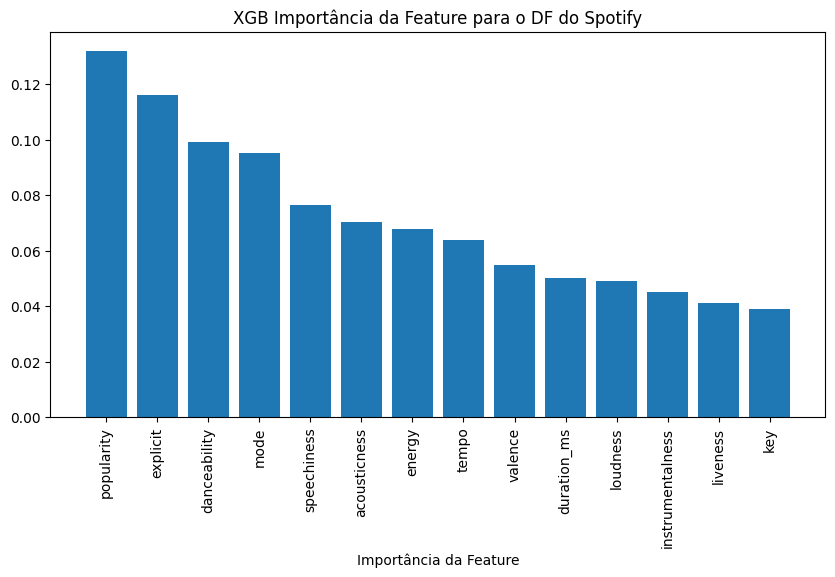

In [16]:
feature_importances = best_xgb.feature_importances_
feature_names = X.columns

# Ordena e plota
sorted_indices = np.argsort(feature_importances)[::-1]
plt.figure(figsize=(10, 5))
plt.bar(range(len(feature_importances)), feature_importances[sorted_indices], align="center")
plt.xticks(range(len(feature_importances)), np.array(feature_names)[sorted_indices], rotation=90)
plt.xlabel("Importância da Feature")
plt.title("XGB Importância da Feature para o DF do Spotify")
plt.show()